Saving tested.csv to tested (8).csv
=== TASK 1: DATA QUALITY ===

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Duplicate Rows: 0

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 

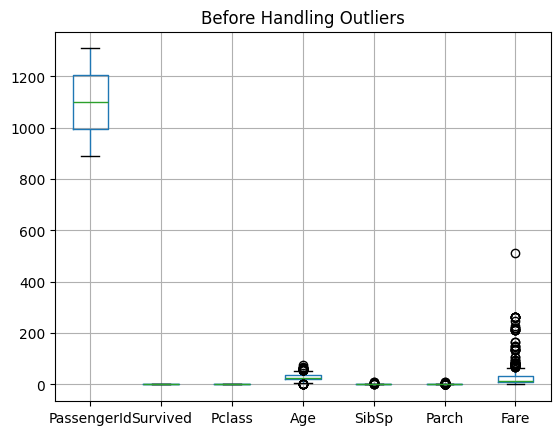

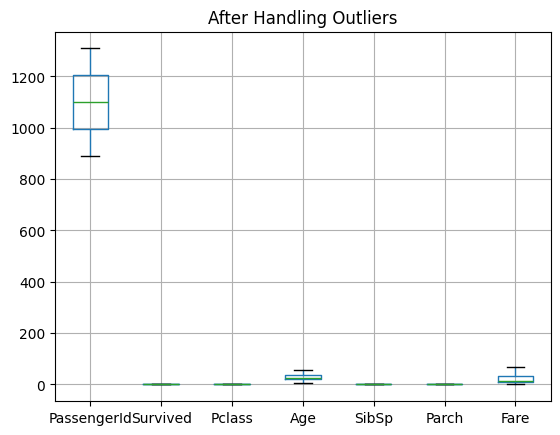


=== TASK 4: NORMALIZATION ===

Min-Max Sample:
    PassengerId  Survived  Pclass       Age  SibSp  Parch      Fare
0     0.000000       0.0     1.0  0.600490    0.0    0.0  0.117140
1     0.002398       1.0     1.0  0.845588    0.4    0.0  0.104734
2     0.004796       0.0     0.5  1.000000    0.0    0.0  0.144944
3     0.007194       0.0     1.0  0.453431    0.0    0.0  0.129608
4     0.009592       1.0     1.0  0.355392    0.4    0.0  0.183846

Z-score Sample:
    PassengerId  Survived    Pclass       Age     SibSp  Parch      Fare
0    -1.727912 -0.755929  0.873482  0.437674 -0.622272    0.0 -0.794366
1    -1.719625  1.322876  0.873482  1.501076  0.949387    0.0 -0.833539
2    -1.711337 -0.755929 -0.315819  2.171019 -0.622272    0.0 -0.706576
3    -1.703050 -0.755929  0.873482 -0.200367 -0.622272    0.0 -0.754999
4    -1.694763  1.322876  0.873482 -0.625728  0.949387    0.0 -0.583747

=== TASK 5: CORRELATION MATRIX ===
             PassengerId  Survived    Pclass       Age     SibS

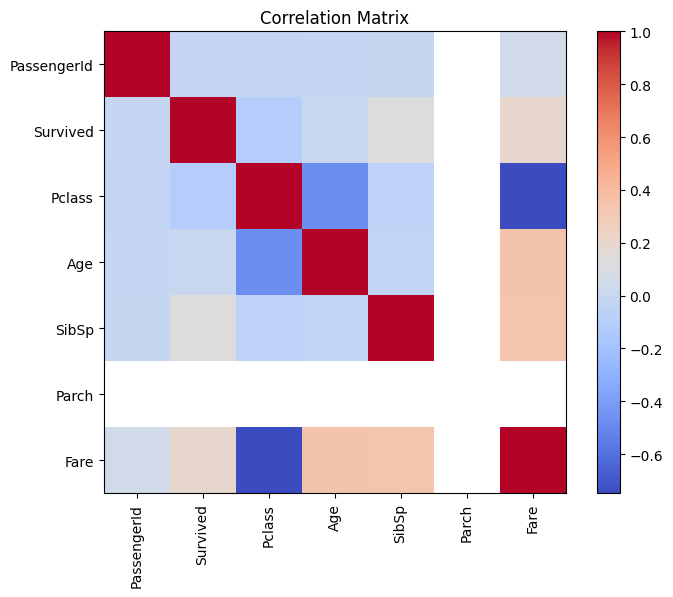


Applying PCA...

Explained Variance Ratio: [0.3591651  0.19432822]


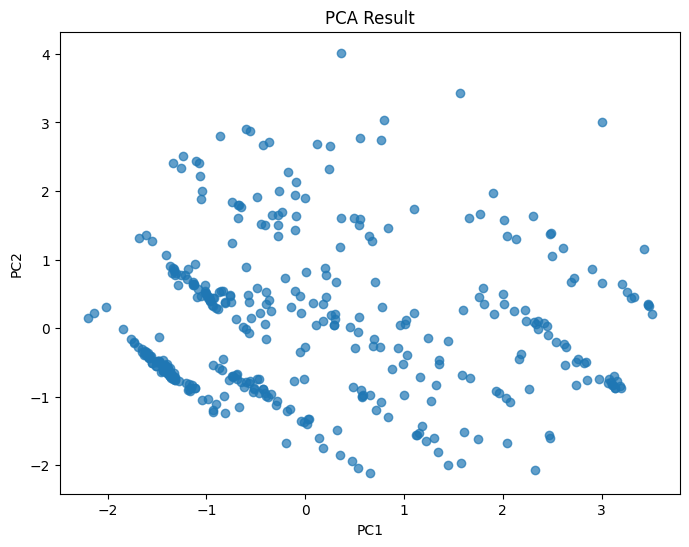

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
# Load dataset

from google.colab import files
uploaded = files.upload()
df = pd.read_csv("tested.csv")

# Task 1: Data Quality
print("=== TASK 1: DATA QUALITY ===")
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nInfo:")
df.info()
print("\nStatistics:\n", df.describe())

# Task 2: Handle Missing Values
print("\n=== TASK 2: BEFORE HANDLING MISSING VALUES ===")
print(df.isnull().sum())

# Fill missing numeric values with median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Drop 'Cabin' if exists
if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin'])

print("\n=== TASK 2: AFTER HANDLING MISSING VALUES ===")
print(df.isnull().sum())

# Task 3: Outliers (IQR)
num_cols = df.select_dtypes(include=np.number).columns

# Before handling outliers
df[num_cols].boxplot()
plt.title("Before Handling Outliers")
plt.show()

# Apply IQR method to cap outliers
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

# After handling outliers
df[num_cols].boxplot()
plt.title("After Handling Outliers")
plt.show()

# Task 4: Normalization
# Ensure no missing numeric values before scaling
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Min-Max Scaling
minmax = MinMaxScaler()
df_minmax = pd.DataFrame(minmax.fit_transform(df[num_cols]), columns=num_cols)

# Z-score Standardization
zscore = StandardScaler()
df_zscore = pd.DataFrame(zscore.fit_transform(df[num_cols]), columns=num_cols)

print("\n=== TASK 4: NORMALIZATION ===")
print("\nMin-Max Sample:\n", df_minmax.head())
print("\nZ-score Sample:\n", df_zscore.head())

# Task 5: Correlation + PCA
corr_matrix = df[num_cols].corr()

print("\n=== TASK 5: CORRELATION MATRIX ===")
print(corr_matrix)

# Visualize correlation matrix
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Matrix")
plt.show()

# PCA
df_zscore_clean = df_zscore.dropna()

# Apply PCA if strong correlations exist
if (corr_matrix.abs() > 0.5).sum().sum() > len(num_cols):
    print("\nApplying PCA...")

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(df_zscore_clean)
    pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

    print("\nExplained Variance Ratio:", pca.explained_variance_ratio_)

    plt.figure(figsize=(8,6))
    plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Result")
    plt.show()
else:
    print("\nPCA not applied (no strong correlation)")